# DataHub Snapshot Quick Inspect

This notebook is for CBOND ON to quickly inspect DataHub `raw/clean snapshot` data.

In [11]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("pandas", pd.__version__)

pandas 3.0.1


In [12]:
# Update these paths only if your DataHub root changed.
RAW_ROOT = Path(r"D:/cbond_data_hub/raw_data/snapshot/cbond/raw_data")
CLEAN_ROOT = Path(r"D:/cbond_data_hub/clean_data/snapshot/cbond")
CLEAN_ROOT_LEGACY = Path(r"D:/cbond_data_hub/clean_data/snapshot")

# Optional manual override, e.g. "2026-03-18". Keep None to auto-pick latest common day.
TARGET_DAY = None

for p in [RAW_ROOT, CLEAN_ROOT, CLEAN_ROOT_LEGACY]:
    print(p, "exists=", p.exists())

D:\cbond_data_hub\raw_data\snapshot\cbond\raw_data exists= True
D:\cbond_data_hub\clean_data\snapshot\cbond exists= True
D:\cbond_data_hub\clean_data\snapshot exists= True


In [13]:
def list_days(root: Path) -> list[str]:
    if not root.exists():
        return []
    days = []
    for path in root.glob("*/*.parquet"):
        name = path.stem
        if len(name) == 8 and name.isdigit():
            days.append(name)
    return sorted(set(days))

raw_days = list_days(RAW_ROOT)
clean_days = list_days(CLEAN_ROOT) if CLEAN_ROOT.exists() else list_days(CLEAN_ROOT_LEGACY)

common_days = sorted(set(raw_days).intersection(clean_days))
if TARGET_DAY is None:
    if not common_days:
        raise RuntimeError("No common days found between raw and clean roots.")
    day = common_days[-1]
else:
    day = TARGET_DAY.replace("-", "")

month = f"{day[:4]}-{day[4:6]}"
raw_path = RAW_ROOT / month / f"{day}.parquet"
clean_path = (CLEAN_ROOT / month / f"{day}.parquet") if (CLEAN_ROOT / month / f"{day}.parquet").exists() else (CLEAN_ROOT_LEGACY / month / f"{day}.parquet")

print("target day:", day)
print("raw_path:", raw_path)
print("clean_path:", clean_path)
print("raw exists:", raw_path.exists(), "clean exists:", clean_path.exists())
print("raw days:", len(raw_days), "clean days:", len(clean_days), "common days:", len(common_days))

target day: 20260318
raw_path: D:\cbond_data_hub\raw_data\snapshot\cbond\raw_data\2026-03\20260318.parquet
clean_path: D:\cbond_data_hub\clean_data\snapshot\cbond\2026-03\20260318.parquet
raw exists: True clean exists: True
raw days: 290 clean days: 184 common days: 184


In [ ]:
raw_df = pd.read_parquet(raw_path)
clean_df = pd.read_parquet(clean_path)

print("raw shape:", raw_df.shape)
print("clean shape:", clean_df.shape)

raw_cols = set(raw_df.columns)
clean_cols = set(clean_df.columns)
print("raw only cols:", sorted(raw_cols - clean_cols))
print("clean only cols:", sorted(clean_cols - raw_cols))

display(pd.DataFrame({"raw_columns": sorted(raw_cols), "clean_columns": pd.Series(sorted(clean_cols))}))
raw_df

raw shape: (1522674, 41)
clean shape: (1519641, 41)
raw only cols: []
clean only cols: []


,raw_columns,clean_columns
0,__index_level_0__,__index_level_0__
1,amount,amount
2,ask_price1,ask_price1
3,ask_price2,ask_price2
4,ask_price3,ask_price3
5,ask_price4,ask_price4
6,ask_price5,ask_price5
7,ask_volume1,ask_volume1
8,ask_volume2,ask_volume2
9,ask_volume3,ask_volume3


In [15]:
# Core fields quick view
core_cols = [
    "code", "trade_time", "last", "open", "high", "low", "close",
    "volume", "amount", "trading_phase_code",
    "ask_price1", "ask_volume1", "bid_price1", "bid_volume1",
]
use_cols = [c for c in core_cols if c in clean_df.columns]
sample = clean_df[use_cols].head(10)
display(sample)

null_ratio = clean_df[use_cols].isna().mean().sort_values(ascending=False)
display(null_ratio.to_frame("null_ratio"))

,code,trade_time,last,open,high,low,close,volume,amount,trading_phase_code,ask_price1,ask_volume1,bid_price1,bid_volume1
0,000001,2026-03-18 09:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,110070.SH,2026-03-18 09:15:03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.600,980.0,118.600,980.0
2,110070.SH,2026-03-18 09:15:12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.600,980.0,118.600,980.0
3,110070.SH,2026-03-18 09:15:18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
4,110070.SH,2026-03-18 09:15:21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
5,110070.SH,2026-03-18 09:15:24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
6,110070.SH,2026-03-18 09:15:27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
7,110070.SH,2026-03-18 09:15:33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
8,110070.SH,2026-03-18 09:15:36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.501,980.0,118.501,980.0
9,110070.SH,2026-03-18 09:15:39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,118.629,1550.0,118.629,1550.0


,null_ratio
open,6.580502e-07
last,6.580502e-07
high,6.580502e-07
low,6.580502e-07
volume,6.580502e-07
close,6.580502e-07
ask_price1,6.580502e-07
ask_volume1,6.580502e-07
amount,6.580502e-07
trading_phase_code,6.580502e-07


In [16]:
for df_name, df in [("raw", raw_df), ("clean", clean_df)]:
    if "trade_time" not in df.columns:
        print(df_name, "missing trade_time")
        continue
    tt = pd.to_datetime(df["trade_time"], errors="coerce")
    print(
        f"{df_name}: trade_time min={tt.min()} max={tt.max()} unique_codes={df['code'].nunique() if 'code' in df.columns else 'N/A'} rows={len(df)}"
    )

raw: trade_time min=2026-03-18 09:15:03 max=2026-03-18 14:59:47 unique_codes=363 rows=1522674
clean: trade_time min=2026-03-18 09:15:03 max=2026-03-18 14:59:47 unique_codes=363 rows=1519641


In [17]:
# Estimate sampling interval from clean snapshot (seconds)
if {"code", "trade_time"}.issubset(clean_df.columns):
    work = clean_df[["code", "trade_time"]].copy()
    work["trade_time"] = pd.to_datetime(work["trade_time"], errors="coerce")
    work = work.dropna().sort_values(["code", "trade_time"])
    diff_sec = work.groupby("code")["trade_time"].diff().dt.total_seconds().dropna()
    print("diff count:", len(diff_sec))
    print("median:", float(diff_sec.median()))
    print("q25/q75:", float(diff_sec.quantile(0.25)), float(diff_sec.quantile(0.75)))
    print("q95:", float(diff_sec.quantile(0.95)))
    display(diff_sec.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("sec"))
else:
    print("clean data missing code/trade_time")

diff count: 1519278
median: 3.0
q25/q75: 3.0 3.0
q95: 6.0


,sec
count,1.519278e+06
mean,4.918039e+00
std,7.936049e+01
min,3.000000e+00
10%,3.000000e+00
25%,3.000000e+00
50%,3.000000e+00
75%,3.000000e+00
90%,3.000000e+00
95%,6.000000e+00


sample code: 110092.SH rows: 5027


,trade_time,last
57020,2026-03-18 09:15:03,0.0
57021,2026-03-18 09:15:06,0.0
57022,2026-03-18 09:15:09,0.0
57023,2026-03-18 09:15:12,0.0
57024,2026-03-18 09:15:15,0.0
57025,2026-03-18 09:15:18,0.0
57026,2026-03-18 09:15:21,0.0
57027,2026-03-18 09:15:24,0.0
57028,2026-03-18 09:15:27,0.0
57029,2026-03-18 09:15:30,0.0


,trade_time,last
62037,2026-03-18 14:59:18,113.308
62038,2026-03-18 14:59:21,113.262
62039,2026-03-18 14:59:24,113.215
62040,2026-03-18 14:59:27,113.223
62041,2026-03-18 14:59:30,113.280
62042,2026-03-18 14:59:33,113.233
62043,2026-03-18 14:59:36,113.233
62044,2026-03-18 14:59:39,113.306
62045,2026-03-18 14:59:42,113.311
62046,2026-03-18 14:59:45,113.373


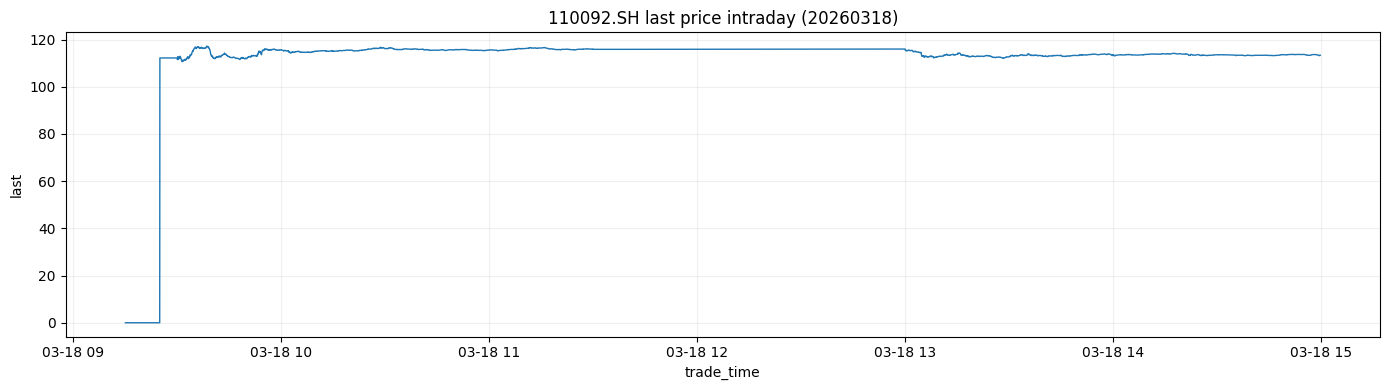

In [18]:
# Pick one active code and inspect intraday last price
if {"code", "trade_time", "last"}.issubset(clean_df.columns):
    cnt = clean_df["code"].value_counts()
    one_code = cnt.index[0]
    one = clean_df.loc[clean_df["code"] == one_code, ["trade_time", "last"]].copy()
    one["trade_time"] = pd.to_datetime(one["trade_time"], errors="coerce")
    one = one.dropna().sort_values("trade_time")
    
    print("sample code:", one_code, "rows:", len(one))
    display(one.head(10))
    display(one.tail(10))

    plt.figure(figsize=(14, 4))
    plt.plot(one["trade_time"], one["last"], lw=1)
    plt.title(f"{one_code} last price intraday ({day})")
    plt.xlabel("trade_time")
    plt.ylabel("last")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("clean data missing code/trade_time/last")

In [19]:
# Recent day-level row count check (raw vs clean)
def daily_row_count(root: Path, days: list[str], tail_n: int = 10) -> pd.DataFrame:
    rows = []
    for d in days[-tail_n:]:
        p = root / f"{d[:4]}-{d[4:6]}" / f"{d}.parquet"
        if p.exists():
            try:
                n = len(pd.read_parquet(p, columns=["code"]))
            except Exception:
                n = len(pd.read_parquet(p))
        else:
            n = np.nan
        rows.append({"day": d, "rows": n, "path": str(p)})
    return pd.DataFrame(rows)

recent_days = common_days[-10:] if len(common_days) >= 1 else []
raw_cnt = daily_row_count(RAW_ROOT, recent_days, tail_n=len(recent_days)).rename(columns={"rows": "raw_rows"})
clean_cnt = daily_row_count(CLEAN_ROOT if CLEAN_ROOT.exists() else CLEAN_ROOT_LEGACY, recent_days, tail_n=len(recent_days)).rename(columns={"rows": "clean_rows"})

cmp = raw_cnt[["day", "raw_rows"]].merge(clean_cnt[["day", "clean_rows"]], on="day", how="outer")
cmp["diff"] = cmp["raw_rows"] - cmp["clean_rows"]
display(cmp.sort_values("day"))

,day,raw_rows,clean_rows,diff
0,20260226,1517868,1493505,24363
1,20260227,1580312,1557020,23292
2,20260302,1620992,1597397,23595
3,20260303,1626544,1602712,23832
4,20260311,1524901,1499892,25009
5,20260312,1557655,1531492,26163
6,20260313,1529326,1506146,23180
7,20260316,1590450,1561133,29317
8,20260317,1323935,1294214,29721
9,20260318,1522674,1519641,3033
